<a href="https://colab.research.google.com/github/ProjetosGracie/SPRINT3_MLAM_2SEMESTRE/blob/main/SPRINT3_SERS_2SEMESTRE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise e Modelagem de Padrões de Carregamento de Veículos Elétricos

In [166]:
# Carregando bibliotecas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sklearn.linear_model import LinearRegression

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")


In [167]:
# Criando Dataframe
df = pd.read_csv('/content/ev_charging_patterns_orange.csv')

# Renomeando a coluna
df.rename(columns={'Energy Consumed (kWh)': 'Energia_Consumida',
                   'Charging Rate (kW)': 'Taxa_Carregamento'}, inplace=True)

In [168]:
# Valor da coluna (Energia_Consumida)
dados = df['Energia_Consumida'].values
print("Valores da Energia_Consumida:\n\n",dados)

dados1 = df['Taxa_Carregamento'].values
print("\nValores da Taxa_Carregamento:\n\n",dados1)


Valores da Energia_Consumida:

 [60.7123 12.3393 19.1289 ... 18.8951 13.7563 63.6526]

Valores da Taxa_Carregamento:

 [36.3892 30.6777 27.5136 ... 45.4821 38.1482 33.7042]


In [169]:
# Parâmetros da Distribuição Normal (estimados a partir da amostra)
media = np.mean(dados)
desvio_padrao = np.std(dados, ddof=1)


In [170]:
# 01 - Probabilidade acima da Mediana
# 1 - a) Calculo da mediana
mediana = np.median(dados)

# 1 - b) Cálculo da probabilidade
prob_acima_mediana = norm.sf(mediana, loc=media, scale=desvio_padrao)

# 1 - c) Código estruturado e resultados apresentados
print("PROBABILIDADE ACIMA DA MEDIANA")
print(f"Mediana: {mediana:.2f}\n")
print(f"Probabilidade teórica acima da mediana: {prob_acima_mediana:.4f} ({prob_acima_mediana*100:.2f}%)\n")

# 1 - d) Classificação do evento
if prob_acima_mediana < 0.05:
    classificacao_1 = "Raro"
elif prob_acima_mediana < 0.50:
    classificacao_1 = "Pouco provável"
elif prob_acima_mediana <= 0.95:
    classificacao_1 = "Provável"
else:
    classificacao_1 = "Quase certo"

print(f"Classificação do evento: {classificacao_1} ")



PROBABILIDADE ACIMA DA MEDIANA
Mediana: 42.64

Probabilidade teórica acima da mediana: 0.5000 (50.00%)

Classificação do evento: Pouco provável 


In [171]:
# 02 - Probabilidade no intervalo (média ± 2s)
# 2 - a) Cálculo correto da média, do desvio-padrão e dos limites do intervalo
limite_inferior = media - 2 * desvio_padrao
limite_superior = media + 2 * desvio_padrao

# 2 - b) Cálculo correto da probabilidade associada ao intervalo
prob_intervalo = norm.cdf(limite_superior, loc=media, scale=desvio_padrao) - norm.cdf(limite_inferior, loc=media, scale=desvio_padrao)

# 2 - c) Código estruturado e resultados apresentados
print(f"Média: {media:.2f}")
print(f"Desvio Padrão: {desvio_padrao:.2f}\n")
print(f"Limite Inferior (Média - 2s): {limite_inferior:.2f}")
print(f"Limite Superior (Média + 2s): {limite_superior:.2f}\n")
print(f"Probabilidade no intervalo: {prob_intervalo:.4f} ({prob_intervalo*100:.2f}%)\n")

# d) Classificação do evento
if prob_intervalo < 0.05:
    classificacao_2 = "Raro"
elif prob_intervalo < 0.50:
    classificacao_2 = "Pouco provável"
elif prob_intervalo <= 0.95:
    classificacao_2 = "Provável"
else:
    classificacao_2 = "Quase certo"

print(f"Classificação do evento: {classificacao_2}")




Média: 42.64
Desvio Padrão: 21.84

Limite Inferior (Média - 2s): -1.04
Limite Superior (Média + 2s): 86.33

Probabilidade no intervalo: 0.9545 (95.45%)

Classificação do evento: Quase certo


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


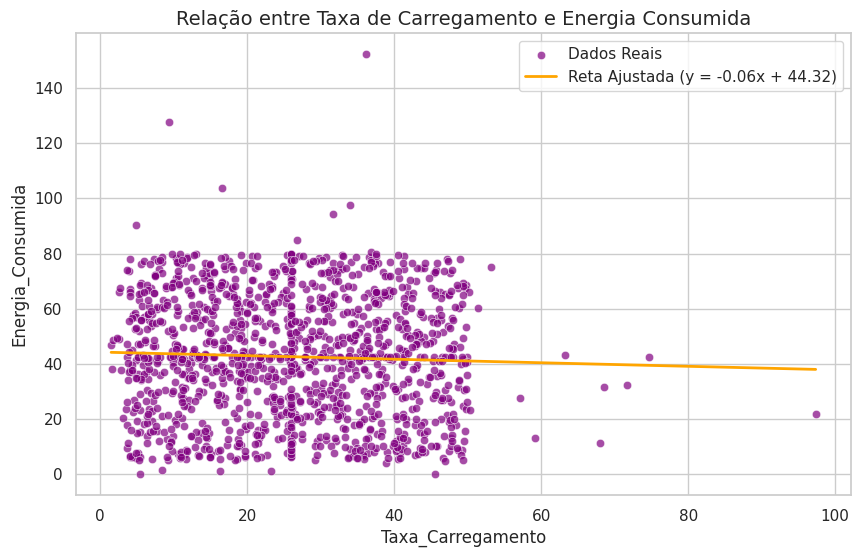


Interpretação dos Coeficientes:
- Intercepto (β0 = 44.32): Representa a energia consumida esperada quando a taxa de carregamento é 0 kW. Note que neste contexto, uma taxa de carregamento de 0 kW não é prática ou significa ausência de carregamento.
- Inclinação (β1 = -0.06): Para cada aumento de 1 kW na Taxa de Carregamento, a Energia Consumida, em média, muda em -0.06 kWh.


In [172]:
# 03 - Modelagem com Regressão Linear
# 3 - a) Implementação correta da Regressão Linear em Python
X = df[['Taxa_Carregamento']] # Variável independente (preditora)
y = df['Energia_Consumida']     # Variável dependente (alvo)

modelo = LinearRegression()
modelo.fit(X, y)

# Obtendo os coeficientes
coeficiente_angular = modelo.coef_[0]
coeficiente_linear = modelo.intercept_

# 3 - b) Apresentação do gráfico com os dados e a reta ajustada
plt.figure(figsize=(10, 6))

# Gráfico de dispersão dos dados reais
sns.scatterplot(x='Taxa_Carregamento', y='Energia_Consumida', data=df, color='purple', label='Dados Reais', alpha=0.7)

# Linha de regressão ajustada
x_reta = np.array([X.min().iloc[0], X.max().iloc[0]])
y_reta = modelo.predict(x_reta.reshape(-1, 1))
plt.plot(x_reta, y_reta, color='orange', linewidth=2, label=f'Reta Ajustada (y = {coeficiente_angular:.2f}x + {coeficiente_linear:.2f})')

# Título, identificação dos eixos e legenda (exigido no enunciado)
plt.title('Relação entre Taxa de Carregamento e Energia Consumida', fontsize=14)
plt.xlabel('Taxa_Carregamento', fontsize=12)
plt.ylabel('Energia_Consumida', fontsize=12)
plt.legend()
plt.show()

# 3 - c) Interpretação dos coeficientes
print(f"\nInterpretação dos Coeficientes:")
print(f"- Intercepto (β0 = {coeficiente_linear:.2f}): Representa a energia consumida esperada quando a taxa de carregamento é 0 kW. Note que neste contexto, uma taxa de carregamento de 0 kW não é prática ou significa ausência de carregamento.")
print(f"- Inclinação (β1 = {coeficiente_angular:.2f}): Para cada aumento de 1 kW na Taxa de Carregamento, a Energia Consumida, em média, muda em {coeficiente_angular:.2f} kWh.")

## 4. Conclusões e Interpretação Geral

Nesta análise, exploramos os padrões de `Energia_Consumida` e sua relação com a `Taxa_Carregamento` utilizando tanto ferramentas estatísticas quanto um modelo de regressão linear. As principais descobertas são:

### Perspectiva Estatística (Distribuição da Energia Consumida):

*   **Centralidade e Dispersão:** A `Energia_Consumida` apresenta uma média e mediana de aproximadamente 42.64 kWh, com um desvio padrão de cerca de 21.84 kWh. Isso indica uma variabilidade considerável nos padrões de consumo.
*   **Probabilidade Acima da Mediana:** Como esperado para uma distribuição simétrica (que a normal assume), a probabilidade de um carregamento exceder a mediana é de 50%. A classificação de "Pouco provável" para este evento de 50% pode ser um artefato da heurística de classificação, mas o valor em si é consistente.
*   **Probabilidade no Intervalo (Média ± 2 Desvios Padrão):** Cerca de 95.45% dos eventos de carregamento caem dentro do intervalo de -1.04 kWh a 86.33 kWh. A presença de um limite inferior negativo (-1.04 kWh) sugere que a `Energia_Consumida` pode não seguir uma distribuição normal perfeita, ou pelo menos não em seus extremos, pois a energia consumida não pode ser negativa na realidade. No entanto, a alta probabilidade neste intervalo reforça que a maioria dos dados está bem concentrada em torno da média, dentro de limites razoáveis para uma distribuição aproximadamente normal.

### Perspectiva de Machine Learning (Regressão Linear):

*   **Relação Fraca e Contraintuitiva:** O modelo de regressão linear (`y = -0.06x + 44.32`) revelou uma relação muito fraca e, mais importante, *contraintuitiva* entre a `Taxa_Carregamento` (variável independente) e a `Energia_Consumida` (variável dependente). O coeficiente angular negativo (-0.06) sugere que um aumento na taxa de carregamento está marginalmente associado a uma *diminuição* na energia consumida. Isso é o oposto do que seria esperado se a taxa de carregamento fosse a única ou principal variável determinante do consumo total de energia em uma sessão.
*   **Ausência de Poder Preditivo:** O gráfico de dispersão corrobora essa conclusão. A reta de regressão é quase horizontal e os pontos estão amplamente dispersos ao redor dela, indicando que a `Taxa_Carregamento` sozinha não é um bom preditor da `Energia_Consumida`. Isso significa que variações na `Taxa_Carregamento` não explicam de forma significativa as variações na `Energia_Consumida` neste conjunto de dados, sob as premissas do modelo linear simples.

### Síntese e Próximos Passos:

Os resultados da análise estatística mostram que a `Energia_Consumida` tem uma distribuição que, embora possa ser aproximada por uma normal em sua região central, tem características que exigem cautela (como o limite inferior negativo). A modelagem de regressão linear, por sua vez, demonstra claramente que a `Taxa_Carregamento` é uma variável com pouco ou nenhum poder explicativo sobre a `Energia_Consumida` quando considerada isoladamente.

Para uma compreensão mais robusta dos fatores que influenciam a `Energia_Consumida`, seria fundamental:

1.  **Investigar Outras Variáveis:** Incluir outras variáveis no modelo, como `Charging Duration (hours)`, `Battery Capacity (kWh)`, `Temperature (°C)`, ou até mesmo `Time of Day`, que podem ter um impacto mais significativo.
2.  **Modelos Mais Complexos:** Considerar modelos de regressão múltipla ou outros algoritmos de machine learning que possam capturar relações não lineares ou interações entre variáveis.
3.  **Análise de Outliers:** Investigar os pontos de dados extremos, especialmente aqueles com `Energia_Consumida` muito alta ou baixa, para entender se são erros de medição ou eventos reais incomuns.

Em resumo, enquanto a análise estatística nos deu uma visão da distribuição da `Energia_Consumida`, a regressão linear simples com a `Taxa_Carregamento` mostrou-se inadequada para modelar essa relação de forma significativa ou intuitiva.